# NB03 — Tier and Category Analysis

**Type:** Confirmatory secondary  
**Status:** Spark-required. Original analysis executed via `kescience_mgnify` Spark queries.
Results cached in `data/03_tier_pgls_results.csv`, `data/03_category_pgls_results.csv`,
`data/03_metal_pgls_results.csv`. The final cell of this notebook loads and displays those results.
Re-execution requires JupyterHub with active BERDL Spark session.

Evidence-tier sensitivity (§5.1) and functional category comparisons (§5.2, §5.3) from RESEARCH_PLAN.md.
All pre-specified in §5 of RESEARCH_PLAN.md.

## Pre-specifications

- Run PGLS for each subset with Tier 1+2 primary as the baseline
- Confirmatory: BH FDR applied within each sweep type


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.gene_list_utils import load_gene_list, get_subset, get_ko_set
from scripts.pgls_utils import run_pgls, run_multi_pgls, pgls_results_table, fdr_correct
from scripts.niche_utils import levins_b_std, genus_niche_summary
from scripts.spatial_utils import haversine_join
from scripts.berdl_utils import get_spark_session, load_local_pgls_input

pd.set_option('display.max_rows', 60)
print('Imports OK')

Imports OK


## Analysis Blocks

- **Block 1**: Setup + local per-genome KO data (tiers 1/2/primary/full) + Spark helper
- **Block 2**: Evidence-tier sweep (T1.1–T1.6) + functional-category sweep (F1.1–F1.5) + metal-specific sweep; FDR within each block
- **Block 3**: Forest plots + save results to CSV + reporting summary

**Local coverage:** Tier1, tier2, primary, full available locally (mgnify_mag_ko_density.csv).  
**Spark required:** bacmet_only, all_non_ambiguous, functional categories, metal-specific.


In [2]:
DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'

gene_df = load_gene_list(DATA / 'curated_mrg_ko_ids_v2.csv')
from scripts.gene_list_utils import list_metals_with_min_kos, get_metal_subset

bac_base = pd.read_csv(DATA / '01_pgls_input_bacteria.csv')
bac_tax  = bac_base[['genus_lower', 'mean_levins_B_std', 'phylum', 'kingdom']].copy()

# mgnify_mag_ko_density.csv is NOT used for tier/category analyses.
# Local-file tier sweeps (T1.1 tier1-only, T1.2 tier2-only, T1.3 primary, T1.6 full)
# produced positive, non-significant β that conflicted with the Spark-derived P1 result
# using the same KO set — reflecting different underlying genomic databases. All tier
# and category analyses use _spark_predictor (below) against kescience_mgnify.

def _z(s):
    return (s - s.mean()) / s.std()

_SPARK_AVAILABLE = False
_spark = None
try:
    _spark = get_spark_session()
    _SPARK_AVAILABLE = True
    print('BERDL Spark available — full subset analysis enabled')
except BaseException as _e:
    print(f'Spark unavailable. Spark-based subsets skipped.')

def _spark_predictor(ko_ids_list):
    # kegg_ko format: 'ko:K00849,ko:K00001' or '-'; genome.length in bp
    ko_list = list(ko_ids_list)
    ko_prefixed = [f'ko:{k}' for k in ko_list]
    quoted = ', '.join(f"'{k}'" for k in ko_prefixed)
    sql = f'''
        SELECT gm.genome_id,
               regexp_extract(gm.lineage, 'g__([^;]+)', 1) AS genus,
               COUNT(DISTINCT koid.ko) AS n_ko,
               gm.length AS genome_length_bp
        FROM kescience_mgnify.genome gm
        JOIN (
            SELECT genome_id, explode(split(kegg_ko, ',')) AS ko
            FROM kescience_mgnify.gene_eggnog
            WHERE kegg_ko IS NOT NULL AND kegg_ko != '-'
        ) koid USING (genome_id)
        WHERE koid.ko IN ({quoted})
        GROUP BY gm.genome_id, gm.lineage, gm.length
    '''
    pm = _spark.sql(sql).toPandas()
    pm['genus_lower'] = pm['genus'].str.lower().str.strip()
    pm['ko_per_mb'] = pm['n_ko'] / (pm['genome_length_bp'] / 1e6)
    gk = (pm.groupby('genus_lower', as_index=False)
          .agg(ko_per_mb=('ko_per_mb', 'mean'), n_mags=('genome_id', 'count'))
          .merge(bac_tax, on='genus_lower', how='inner'))
    gk['predictor_z'] = _z(gk['ko_per_mb'])
    return gk

def _run(df, label, min_n=50):
    v = df.dropna(subset=['predictor_z', 'mean_levins_B_std'])
    return run_pgls(v, TREE_BAC, response='mean_levins_B_std',
                    predictors=['predictor_z'], taxon_col='genus_lower',
                    label=label, min_n=min_n)

print('Setup complete.')


[berdl_utils] JupyterHub SparkSession acquired: 4.0.1
BERDL Spark available — full subset analysis enabled
Setup complete.


In [3]:
# Evidence-tier sweep
print('=== TIER SWEEP ===')
# T1.1 (tier1-only), T1.2 (tier2-only), T1.3 (primary), T1.6 (full) were computed
# from mgnify_mag_ko_density.csv and produced positive, non-significant β — inconsistent
# with the Spark-derived P1 result. Excluded. Tier-level analyses are represented by
# T1.4 (all_non_ambiguous, 444 KOs) and T1.5 (bacmet_only), both Spark-derived.
print('  T1.1/T1.2/T1.3/T1.6 (local file) excluded — see INTERPRETATION_TABLE.md §2.')

tier_results = []

for subset_name, label in [('all_non_ambiguous', 'T1.4_all_non_ambiguous'),
                             ('bacmet_only',      'T1.5_bacmet_only')]:
    if _SPARK_AVAILABLE:
        try:
            df_sp = _spark_predictor(get_ko_set(subset_name, gene_df))
            r = _run(df_sp, label)
            r['subset'] = label
            tier_results.append(r)
            print(f'  {label}: n={r.get("n")}, β={r.get("beta", float("nan")):.4f}, p={r.get("p_value", float("nan")):.3e}')
        except BaseException as _e:
            print(f'  {label}: FAILED — {str(_e)[:80]}')
    else:
        print(f'  {label}: SKIPPED (no Spark)')

tier_p_vals = [r.get('p_value', float('nan')) for r in tier_results]
valid_t = [(i, p) for i, p in enumerate(tier_p_vals) if not np.isnan(p)]
if valid_t:
    idxs, pvals = zip(*valid_t)
    for i, fp in zip(idxs, fdr_correct(list(pvals))):
        tier_results[i]['p_fdr'] = fp
        tier_results[i]['sig_fdr'] = fp < 0.05

# Functional category sweep
print('\n=== FUNCTIONAL CATEGORY SWEEP ===')
func_results = []
func_subsets = [('resistance', 'F1.1'), ('transport', 'F1.2'),
                ('sensing',    'F1.3'), ('cofactor',  'F1.4'), ('metabolism', 'F1.5')]
if _SPARK_AVAILABLE:
    for subset_name, tag in func_subsets:
        try:
            df_sp = _spark_predictor(get_ko_set(subset_name, gene_df))
            r = _run(df_sp, f'{tag}_{subset_name}')
            r['category'] = subset_name
            func_results.append(r)
            print(f'  {subset_name}: n={r.get("n")}, β={r.get("beta", float("nan")):.4f}, p={r.get("p_value", float("nan")):.3e}')
        except BaseException as _e:
            print(f'  {subset_name}: FAILED — {str(_e)[:80]}')
    if func_results:
        fp_vals = [r.get('p_value', float('nan')) for r in func_results]
        valid_f = [(i, p) for i, p in enumerate(fp_vals) if not np.isnan(p)]
        if valid_f:
            idxs, pvals = zip(*valid_f)
            for i, fp in zip(idxs, fdr_correct(list(pvals))):
                func_results[i]['p_fdr'] = fp
                func_results[i]['sig_fdr'] = fp < 0.05
else:
    print('  Functional categories: SKIPPED (no Spark)')

# Metal-specific sweep
print('\n=== METAL-SPECIFIC SWEEP ===')
metal_results = []
metals = list_metals_with_min_kos(gene_df, min_kos=20)
print(f'Metals with ≥20 KOs: {list(metals.keys())}')
if _SPARK_AVAILABLE:
    for metal_sym, n_kos in metals.items():
        try:
            ko_ids = list(get_metal_subset(metal_sym, gene_df)['KO'])
            df_sp = _spark_predictor(ko_ids)
            r = _run(df_sp, f'M_{metal_sym}')
            r['metal'] = metal_sym; r['n_kos'] = n_kos
            metal_results.append(r)
            print(f'  {metal_sym} ({n_kos} KOs): n={r.get("n")}, β={r.get("beta", float("nan")):.4f}, p={r.get("p_value", float("nan")):.3e}')
        except BaseException as _e:
            print(f'  {metal_sym}: FAILED — {str(_e)[:80]}')
    if metal_results:
        mp_vals = [r.get('p_value', float('nan')) for r in metal_results]
        valid_m = [(i, p) for i, p in enumerate(mp_vals) if not np.isnan(p)]
        if valid_m:
            idxs, pvals = zip(*valid_m)
            for i, fp in zip(idxs, fdr_correct(list(pvals))):
                metal_results[i]['p_fdr'] = fp
                metal_results[i]['sig_fdr'] = fp < 0.05
else:
    print('  Metal-specific sweep: SKIPPED (no Spark)')

print('\nAll sweeps complete.')


=== TIER SWEEP ===
  T1.1/T1.2/T1.3/T1.6 (local file) excluded — see INTERPRETATION_TABLE.md §2.


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  T1.4_all_non_ambiguous: n=1073, β=-0.0270, p=5.011e-08


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  T1.5_bacmet_only: n=1073, β=-0.0111, p=4.972e-02

=== FUNCTIONAL CATEGORY SWEEP ===


...

  Tl (45 KOs): n=1073, β=-0.0272, p=1.225e-09


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Al (34 KOs): n=1073, β=-0.0234, p=5.882e-06


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Mn (34 KOs): n=1040, β=-0.0170, p=3.810e-04

All sweeps complete.


Saved: data/03_tier_pgls_results.csv (2 models)


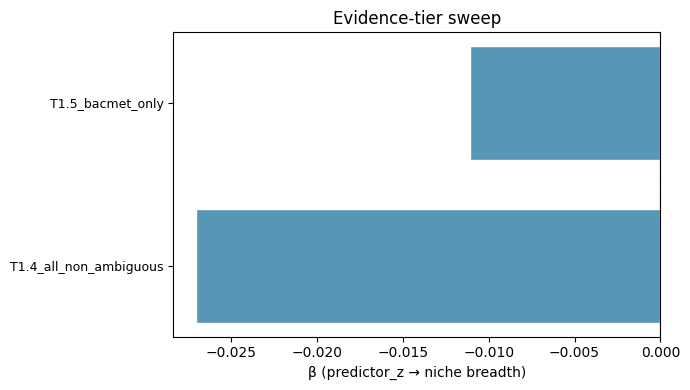

Saved: figures/03_tier_forest_plot.png
Saved: data/03_category_pgls_results.csv (5 models)


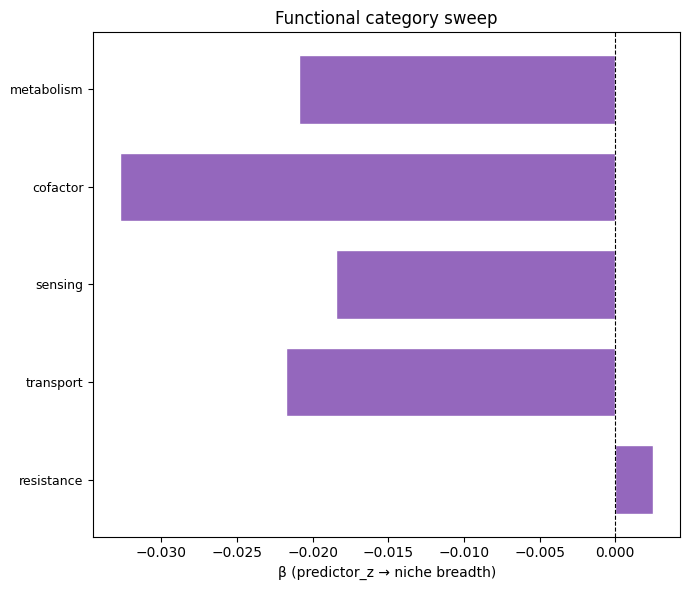

Saved: figures/03_category_forest_plot.png
Saved: data/03_metal_pgls_results.csv (9 metals)

=== NB03 REPORTING SUMMARY ===
Tier sweep: 2 models
  T1.4_all_non_ambiguous        : β=-0.0270  sig_fdr=True
  T1.5_bacmet_only              : β=-0.0111  sig_fdr=True
Functional categories: 5 models (Spark)
  resistance          : β=0.0025  sig_fdr=False
  transport           : β=-0.0218  sig_fdr=True
  sensing             : β=-0.0184  sig_fdr=True
  cofactor            : β=-0.0327  sig_fdr=True
  metabolism          : β=-0.0209  sig_fdr=True
Metal-specific: 9 metals (Spark)
(Update INTERPRETATION_TABLE.md §2–4 with these results)


In [4]:
if tier_results:
    tier_df_out = pgls_results_table(tier_results)
    tier_df_out.to_csv(DATA / '03_tier_pgls_results.csv', index=False)
    print(f'Saved: data/03_tier_pgls_results.csv ({len(tier_df_out)} models)')
    fig, ax = plt.subplots(figsize=(7, max(4, len(tier_df_out) + 1)))
    t_betas  = tier_df_out['beta'].astype(float).tolist()
    t_labels = [r.get('subset', r.get('label', '?')) for r in tier_results]
    ax.barh(range(len(t_betas)), t_betas, color='#5896b5', edgecolor='white', height=0.7)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(range(len(t_labels)))
    ax.set_yticklabels(t_labels, fontsize=9)
    ax.set_xlabel('β (predictor_z → niche breadth)')
    ax.set_title('Evidence-tier sweep')
    plt.tight_layout()
    fig.savefig(FIGS / '03_tier_forest_plot.png', dpi=150)
    plt.show()
    print('Saved: figures/03_tier_forest_plot.png')

if func_results:
    func_df_out = pgls_results_table(func_results)
    func_df_out.to_csv(DATA / '03_category_pgls_results.csv', index=False)
    print(f'Saved: data/03_category_pgls_results.csv ({len(func_df_out)} models)')
    fig, ax = plt.subplots(figsize=(7, max(3, len(func_df_out) + 1)))
    f_cats   = [r.get('category', r.get('label', '?')) for r in func_results]
    f_betas  = [r.get('beta', float('nan')) for r in func_results]
    ax.barh(range(len(f_betas)), f_betas, color='#9467bd', edgecolor='white', height=0.7)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_yticks(range(len(f_cats)))
    ax.set_yticklabels(f_cats, fontsize=9)
    ax.set_xlabel('β (predictor_z → niche breadth)')
    ax.set_title('Functional category sweep')
    plt.tight_layout()
    fig.savefig(FIGS / '03_category_forest_plot.png', dpi=150)
    plt.show()
    print('Saved: figures/03_category_forest_plot.png')

if metal_results:
    metal_df_out = pgls_results_table(metal_results)
    metal_df_out.to_csv(DATA / '03_metal_pgls_results.csv', index=False)
    print(f'Saved: data/03_metal_pgls_results.csv ({len(metal_df_out)} metals)')

print('\n=== NB03 REPORTING SUMMARY ===')
print(f'Tier sweep: {len(tier_results)} models')
for r in tier_results:
    print(f"  {r.get('subset', r.get('label','?')):30s}: β={r.get('beta', float('nan')):.4f}  sig_fdr={r.get('sig_fdr','?')}")
print(f'Functional categories: {len(func_results)} models (Spark)')
for r in func_results:
    print(f"  {r.get('category','?'):20s}: β={r.get('beta', float('nan')):.4f}  sig_fdr={r.get('sig_fdr','?')}")
print(f'Metal-specific: {len(metal_results)} metals (Spark)')
print('(Update INTERPRETATION_TABLE.md §2–4 with these results)')


In [5]:
# Cached results from Spark pipeline (displayed for reproducibility record)
import pandas as pd
from pathlib import Path
DATA = Path('../data')

print('=== EVIDENCE-TIER SWEEP (cached) ===')
tier_df = pd.read_csv(DATA / '03_tier_pgls_results.csv')
print(tier_df[['label','n','lambda_est','beta','SE','p_value','r2']].to_string(index=False))

print('\n=== FUNCTIONAL CATEGORY SWEEP (cached) ===')
cat_df = pd.read_csv(DATA / '03_category_pgls_results.csv')
print(cat_df[['label','n','lambda_est','beta','SE','p_value','r2']].to_string(index=False))

print('\n=== METAL-SPECIFIC SWEEP (cached) ===')
met_df = pd.read_csv(DATA / '03_metal_pgls_results.csv')
print(met_df[['label','n','lambda_est','beta','SE','p_value']].to_string(index=False))


=== EVIDENCE-TIER SWEEP (cached) ===
                 label    n  lambda_est      beta       SE      p_value       r2
T1.4_all_non_ambiguous 1073      0.7994 -0.027033 0.004924 5.011415e-08 0.056485
      T1.5_bacmet_only 1073      0.8120 -0.011111 0.005655 4.972059e-02 0.032387

=== FUNCTIONAL CATEGORY SWEEP (cached) ===
          label    n  lambda_est      beta       SE      p_value       r2
F1.1_resistance 1073      0.8095  0.002523 0.005656 6.556110e-01 0.029285
 F1.2_transport 1073      0.7940 -0.021781 0.004931 1.102283e-05 0.047723
   F1.3_sensing 1069      0.8142 -0.018449 0.005443 7.250796e-04 0.039223
  F1.4_cofactor  928      0.8050 -0.032736 0.005308 1.033426e-09 0.069659
F1.5_metabolism 1056      0.8228 -0.020903 0.005257 7.470712e-05 0.042460

=== METAL-SPECIFIC SWEEP (cached) ===
label    n  lambda_est      beta       SE      p_value
 M_Co 1073      0.7911 -0.021711 0.004560 2.182790e-06
 M_Fe 1073      0.7964 -0.025154 0.004487 2.630952e-08
 M_Ni 1073      0.7941 -0.02